HomeWork 5 - 402125057 - Mobina Haghshenas

# Import Data and Library

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px

df = pd.read_csv(r"Credit Card Customer Data.csv")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


# Data cleaning

## Check for missing values

In [7]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

as we can see, there is no value missing, lets look for possible outliers in our datase.

## Check for outliers

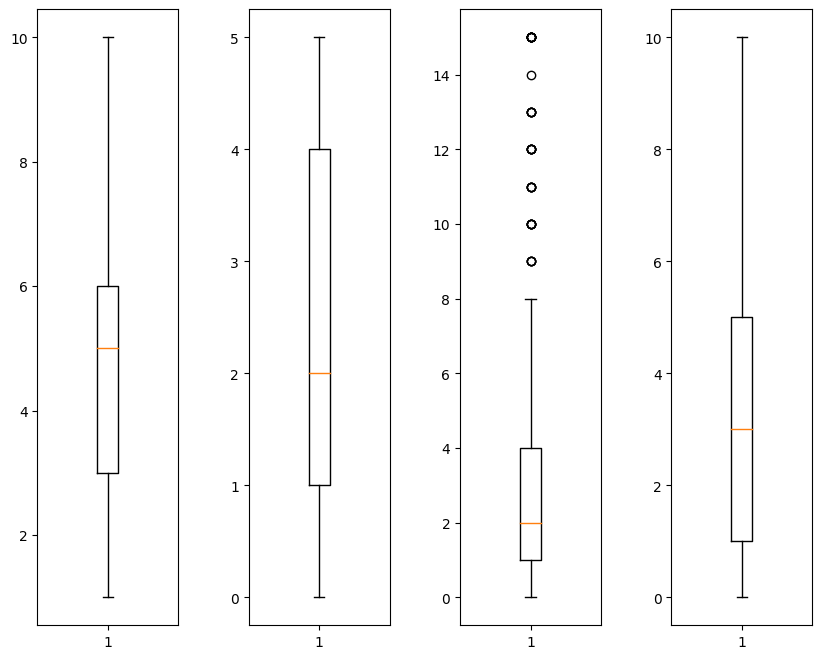

In [8]:
plt.figure(figsize=(10,8))
n = 0
for columns in ['Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online','Total_calls_made']:
    n += 1
    plt.subplot( 1, 4, n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    plt.boxplot(df[columns])

we have some outliers in "Total_visits_online", I'll fix them in next step.

In [9]:

Q1 = df['Total_visits_online'].quantile(0.25)
Q3 = df['Total_visits_online'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['Total_visits_online'] >= lower_bound) & (df['Total_visits_online'] <= upper_bound)]

# Exploratory Data Analysis (EDA)


## Analyze the distribution of each feature using visualizations

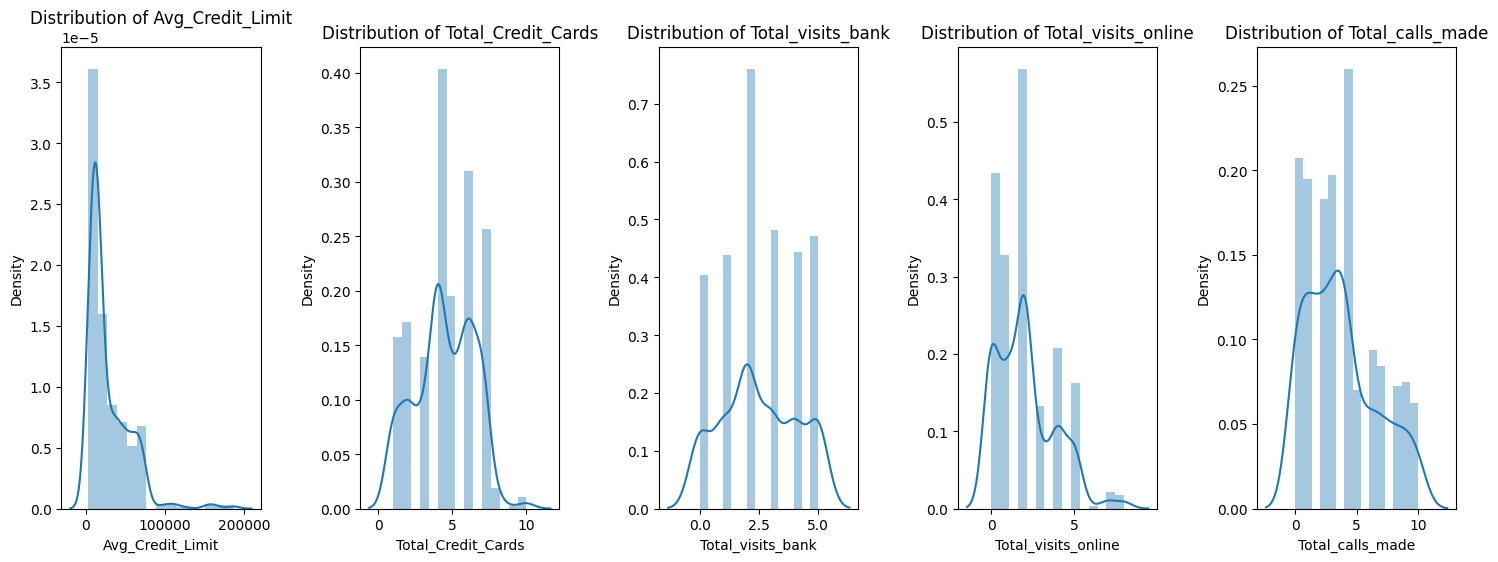

In [10]:
plt.figure(figsize=(18,6))
n = 0
for columns in ['Avg_Credit_Limit' , 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online','Total_calls_made']:
    n += 1
    plt.subplot( 1, 5, n)
    plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
    sns.distplot(df[columns], bins = 15)
    plt.title(f'Distribution of {columns}')

## Calculate descriptive statistics

In [11]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000
mean,315.380417,54824.707865,28316.211878,4.470305,2.512039,2.035313,3.714286
std,180.700801,25556.139821,26758.978607,1.957425,1.610686,1.746482,2.872181
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,159.500000,33413.000000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,315.000000,53814.000000,17000.000000,4.000000,2.000000,2.000000,3.000000
75%,470.500000,76303.500000,41000.000000,6.000000,4.000000,3.000000,6.000000
max,653.000000,99596.000000,187000.000000,10.000000,5.000000,8.000000,10.000000


## Identify potential correlations between features using scatter plots or correlation matrices.


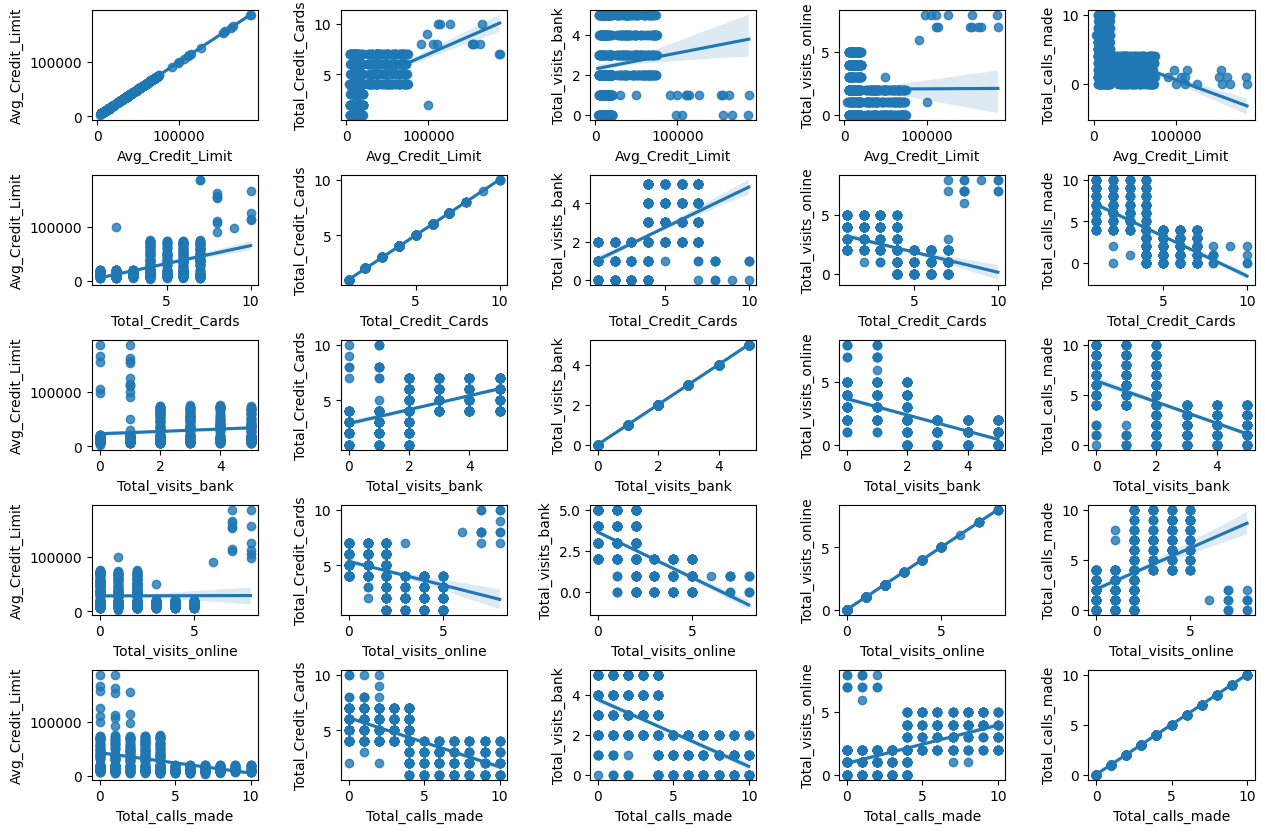

In [12]:
plt.figure(figsize=(15,10))
n = 0
for i in ['Avg_Credit_Limit' , 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online','Total_calls_made']:
    for j in ['Avg_Credit_Limit' , 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online','Total_calls_made']:
        n += 1
        plt.subplot(5,5,n)
        plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
        sns.regplot(x = i, y = j, data=df)

# Model Selection

## K-means

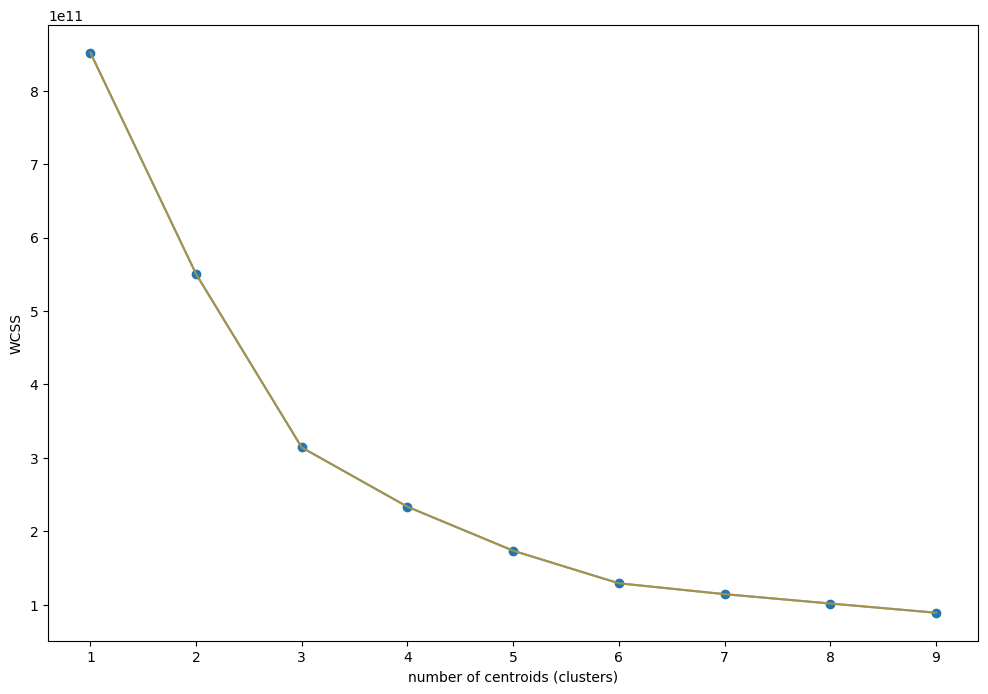

In [13]:
from sklearn.cluster import KMeans
wcss = []
for i in range (1,10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 10, max_iter = 200).fit(df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12,8))
plt.plot(range(1,10), wcss,marker = 'o')
plt.plot(range(1,10), wcss, '-', alpha = 0.6, c = 'orange' )
plt.xlabel('number of centroids (clusters)'), plt.ylabel('WCSS')
plt.show()

The Elbow Method doesn't clearly provide an insight about where the line breaks (where the elbow is).
k can be 3 or 4 so we use silhouette.

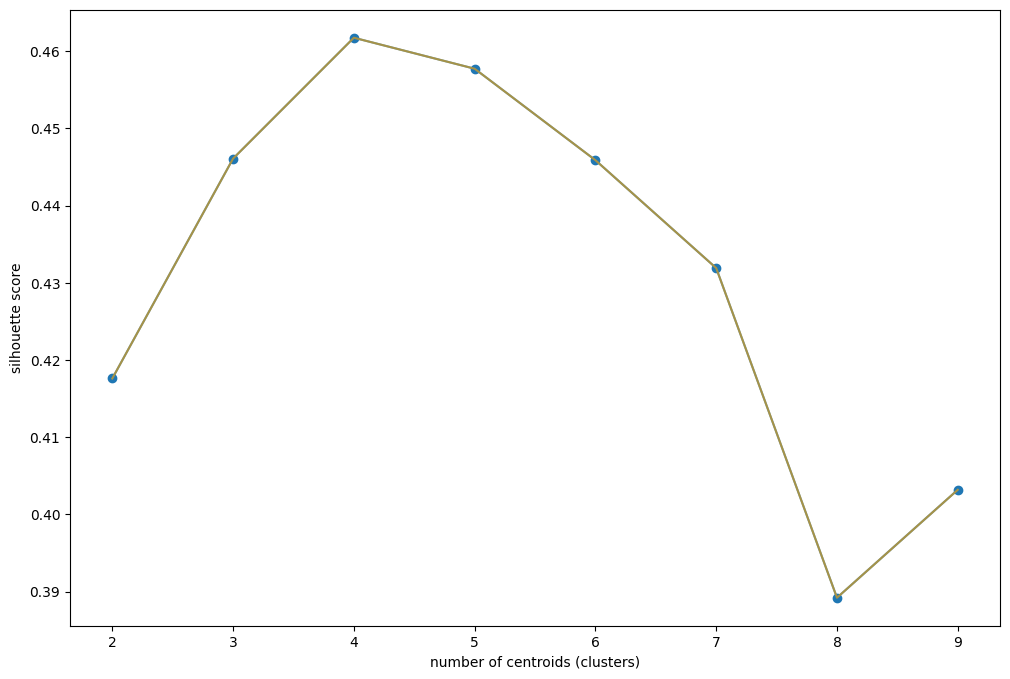

In [14]:
from sklearn.metrics import silhouette_score

sil_score = []
for i in range(2,10):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 10, max_iter=300).fit(df)
    sil_score.append(silhouette_score(df, kmeans.labels_))

plt.figure(figsize=(12,8))
plt.plot(range(2,10), sil_score,marker = 'o')
plt.plot(range(2,10), sil_score, '-', alpha = 0.6, c = 'orange' )
plt.xlabel('number of centroids (clusters)'), plt.ylabel('silhouette score')
plt.show()

In conclution the best K is 4.

## DBSCAN

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

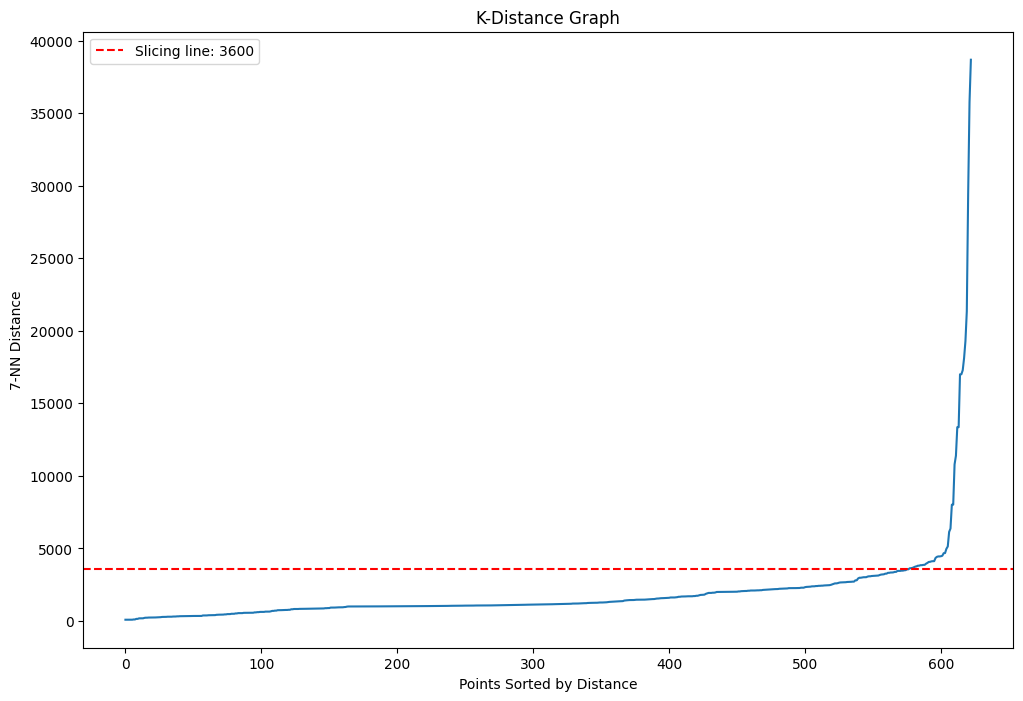

In [49]:
knn = NearestNeighbors(n_neighbors = 7)
model = knn.fit(df)
distances, indices = knn.kneighbors(df)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(12,8))
plt.plot(distances)
plt.xlabel('Points Sorted by Distance')
plt.ylabel('7-NN Distance')
plt.title('K-Distance Graph')
plt.axhline(y= 3600, color='red', linestyle='--', label=f'Slicing line: 3600')
plt.legend()
plt.show()


In [46]:
db = DBSCAN(eps = 3600, min_samples = 6).fit(df)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print('Number of Clusters : ', n_clusters_)
print('Number of Outliers : ', n_noise_)

Number of Clusters :  5
Number of Outliers :  205


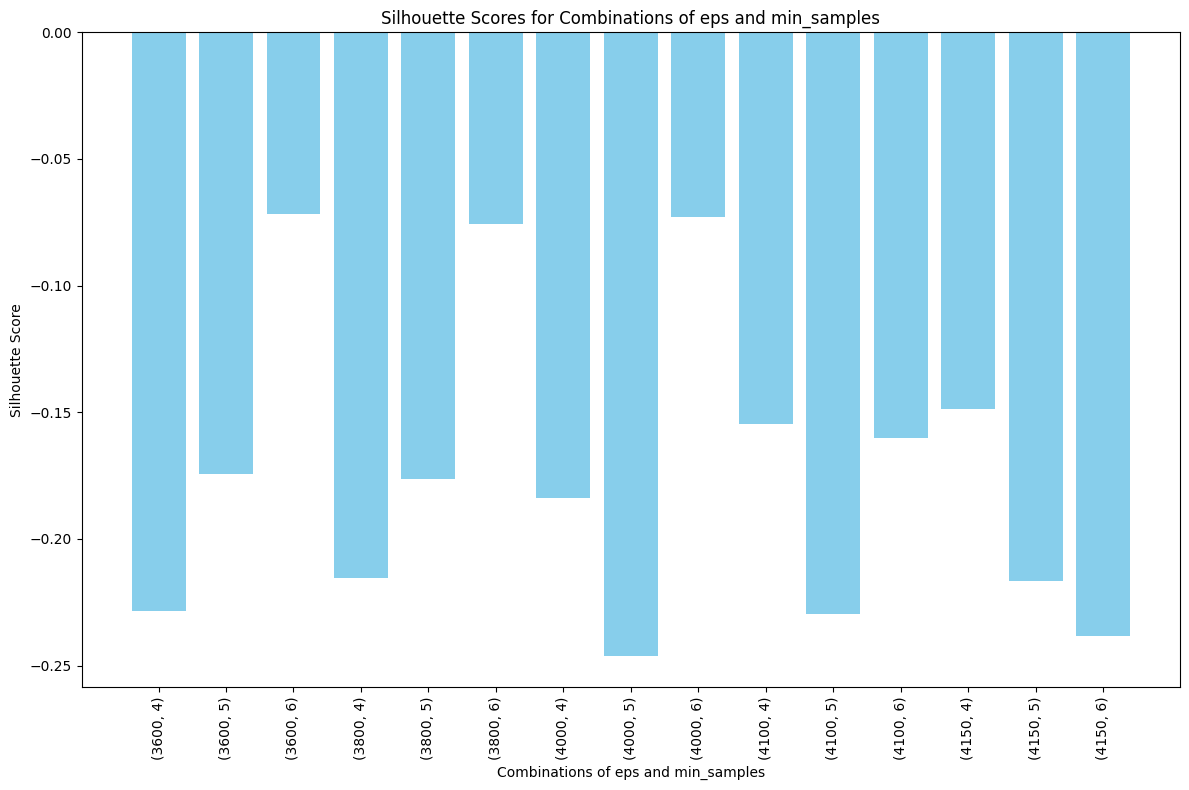

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# Generate random eps and min_samples values
eps_values = [3600, 3800, 4000, 4100, 4150]
min_samples_values = range(4, 7)

# Initialize lists to store combinations and corresponding silhouette scores
combinations = []
silhouette_scores = []

# Iterate over eps and min_samples values
for eps in eps_values:
    for min_samples in min_samples_values:
        # Fit DBSCAN clustering
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df)
        # Calculate Silhouette Score
        silhouette = silhouette_score(df, labels)
        # Store combination and silhouette score
        combinations.append((eps, min_samples))
        silhouette_scores.append(silhouette)

# Plot Silhouette Scores for combinations using a bar chart
plt.figure(figsize=(12, 8))
plt.bar(range(len(combinations)), silhouette_scores, color='skyblue')
plt.xlabel('Combinations of eps and min_samples')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Combinations of eps and min_samples')
plt.xticks(range(len(combinations)), combinations, rotation=90)
plt.tight_layout()
plt.show()


Here we can see the best eps= 4000 and min_samples = 6.

In [48]:
db = DBSCAN(eps = 4000, min_samples = 6).fit(df)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print('Number of Clusters : ', n_clusters_)
print('Number of Outliers : ', n_noise_)

Number of Clusters :  6
Number of Outliers :  195


Now we have a better clustering.